## Introduction

Music has evolved dramatically over the past few decades, driven by changes in technology, streaming platforms, and listener behavior. As Spotify, algorithmic playlists, and short-form content platforms like TikTok became dominant, the structure and sound of popular music shifted—songs grew shorter, louder, more energetic, and increasingly optimized for quick engagement. With Spotify providing rich audio features such as danceability, valence, and energy, it is now possible to quantitatively examine these transformations and understand how modern music differs from earlier eras.

This project explores two interconnected questions: **(1) How has the sound of popular music evolved over time?**
and
**(2) Can we use audio features to predict whether a song will become a hit?** By first examining long-term trends in characteristics such as song duration, loudness, danceability, and emotional tone, we uncover how listener preferences and platform incentives have shaped modern music. Building on this foundation, we develop several machine learning models—including Logistic Regression, Decision Trees, and Random Forests—to classify songs as “hits” or “non-hits.” Finally, we evaluate model performance using ROC curves, AUC scores, and Gain & Lift charts to understand how well these models can support real-world decisions, such as identifying which tracks deserve promotional investment.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Python Group Project/spotify_songs.csv")

print("Shape of data:", df.shape)
df.head()


Shape of data: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


In [ ]:
# Clean Release Date & Extract Year

df["release_date"] = pd.to_datetime(df["track_album_release_date"], errors="coerce")

df = df.dropna(subset=["release_date"])

df["release_year"] = df["release_date"].dt.year

print(df["release_year"].describe())

count    30947.000000
mean      2012.200536
std         10.397763
min       1957.000000
25%       2010.000000
50%       2017.000000
75%       2019.000000
max       2020.000000
Name: release_year, dtype: float64


In [ ]:
# Create "Hit" Label Based on Popularity
# Define a hit as popularity >= 70 (you can tweak threshold if needed)
df["hit"] = (df["track_popularity"] >= 70).astype(int)

df["hit"].value_counts(normalize=True)


,proportion
hit,
0,0.849258
1,0.150742


In [ ]:
# Filter Years with Enough Songs (Minimum 15 songs per year overall)

MIN_SONGS_PER_YEAR = 15

year_counts_all = df["release_year"].value_counts().sort_index()
valid_years_all = year_counts_all[year_counts_all >= MIN_SONGS_PER_YEAR].index

df_year = df[df["release_year"].isin(valid_years_all)].copy()

print("Years kept (overall):")
print(df_year["release_year"].value_counts().sort_index().head(20))


Years kept (overall):
release_year
1967     30
1968     16
1969     48
1970     66
1971     59
1972     41
1973     74
1974     52
1975     67
1976     72
1977     69
1978     89
1979     57
1980     73
1981     46
1982     65
1983     82
1984    104
1985    100
1986     86
Name: count, dtype: int64


In [ ]:

# Check Years with Enough HIT Songs (Minimum 5 hits per year, to avoid noise)

MIN_HITS_PER_YEAR = 5

year_counts_hits = df_year[df_year["hit"] == 1]["release_year"].value_counts().sort_index()
valid_years_hits = year_counts_hits[year_counts_hits >= MIN_HITS_PER_YEAR].index

print("Years with at least", MIN_HITS_PER_YEAR, "hits:")
print(valid_years_hits)


Years with at least 5 hits:
Index([1967, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979,
       1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991,
       1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003,
       2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020],
      dtype='int32', name='release_year')


In [ ]:
# Aggregate Features by Year (All Songs vs Hits)

features = [
    "danceability",
    "energy",
    "loudness",
    "acousticness",
    "instrumentalness",
    "valence",
    "tempo",
    "duration_ms",
]

# Overall yearly averages (all songs)
yearly_all = (
    df_year
    .groupby("release_year")[features + ["track_popularity"]]
    .mean()
    .reset_index()
    .sort_values("release_year")
)

# Convert duration to minutes for interpretability
yearly_all["duration_min"] = yearly_all["duration_ms"] / 60000.0

# Yearly averages for HIT songs only
df_hits_year = df_year[df_year["hit"] == 1 & df_year["release_year"].isin(valid_years_hits)]

yearly_hits = (
    df_hits_year
    .groupby("release_year")[features + ["track_popularity"]]
    .mean()
    .reset_index()
    .sort_values("release_year")
)

yearly_hits["duration_min"] = yearly_hits["duration_ms"] / 60000.0

yearly_all.head(), yearly_hits.head()


(   release_year  danceability    energy  loudness  acousticness  \
 0          1967      0.490667  0.584800 -9.308867      0.335270   
 1          1968      0.450688  0.658062 -9.937437      0.205931   
 2          1969      0.535042  0.651667 -9.101208      0.204765   
 3          1970      0.526379  0.635335 -9.847606      0.239997   
 4          1971      0.522644  0.658864 -9.649627      0.331441   
 
    instrumentalness   valence       tempo    duration_ms  track_popularity  \
 0          0.121278  0.551967  113.434767  225086.366667         47.966667   
 1          0.191999  0.573625  125.940313  249788.812500         56.937500   
 2          0.041839  0.610625  119.523521  229592.437500         48.937500   
 3          0.058393  0.635727  129.565258  246053.151515         41.090909   
 4          0.093942  0.529898  120.457136  304603.745763         43.322034   
 
    duration_min  
 0      3.751439  
 1      4.163147  
 2      3.826541  
 3      4.100886  
 4      5.076729  ,

### Average Popularity of Songs Over Time (All Songs)
- Popularity fluctuates across decades rather than following a strict upward or downward trend.  
- A decline appears around the 1990s–2010, followed by a sharp rise in recent years.  
- These shifts may reflect changes in listener behavior, release volume, and streaming algorithms.


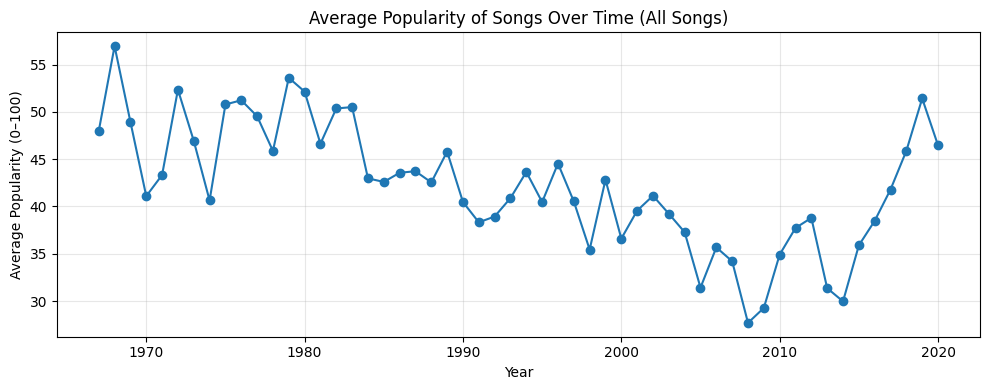

In [ ]:
# Popularity Over Time (All Songs)

plt.figure(figsize=(10, 4))
plt.plot(yearly_all["release_year"], yearly_all["track_popularity"], marker="o")
plt.title("Average Popularity of Songs Over Time (All Songs)")
plt.xlabel("Year")
plt.ylabel("Average Popularity (0–100)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Average Song Duration Over Time: All Songs vs Hits
- Both all songs and hit songs have become shorter over time.  
- Earlier decades featured tracks frequently above 4.5 minutes; modern songs average closer to 3–3.5 minutes.  
- Shorter durations align with streaming-era preferences for quick engagement.


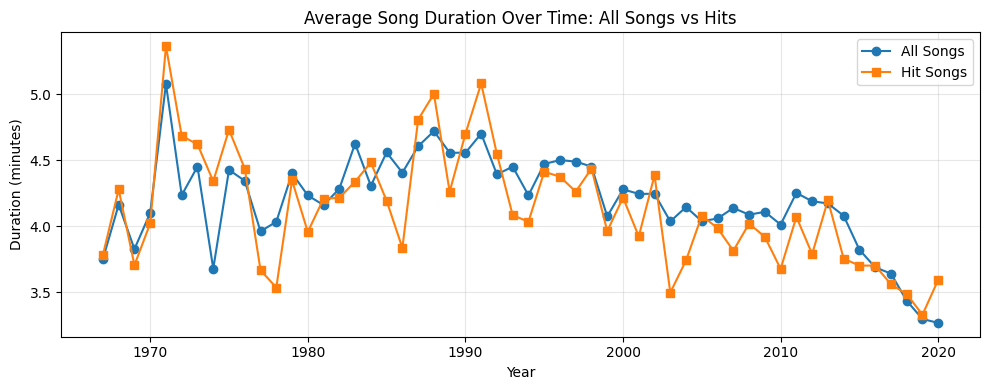

In [ ]:
# Compare Duration of All Songs vs Hits Over Time

plt.figure(figsize=(10, 4))
plt.plot(
    yearly_all["release_year"], yearly_all["duration_min"],
    marker="o", label="All Songs"
)

# Align hits with all-songs years
common_years = np.intersect1d(yearly_all["release_year"], yearly_hits["release_year"])
hits_aligned = yearly_hits[yearly_hits["release_year"].isin(common_years)]
all_aligned = yearly_all[yearly_all["release_year"].isin(common_years)]

plt.plot(
    hits_aligned["release_year"], hits_aligned["duration_min"],
    marker="s", label="Hit Songs"
)

plt.title("Average Song Duration Over Time: All Songs vs Hits")
plt.xlabel("Year")
plt.ylabel("Duration (minutes)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Energy Over Time: All Songs vs Hits
- Overall energy levels rise over time for both groups.  
- Hit songs tend to have consistently higher energy than the general catalog.  
- High-energy production is a strong characteristic of commercially successful tracks.


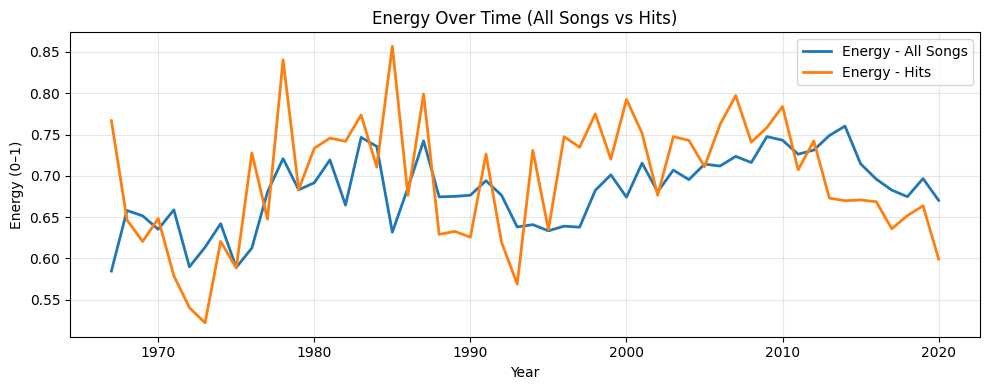

In [ ]:
# Energy Over Time: All vs Hits

plt.figure(figsize=(10, 4))

plt.plot(all_aligned["release_year"], all_aligned["energy"],
         label="Energy - All Songs", linewidth=2)
plt.plot(hits_aligned["release_year"], hits_aligned["energy"],
         label="Energy - Hits", linewidth=2)

plt.title("Energy Over Time (All Songs vs Hits)")
plt.xlabel("Year")
plt.ylabel("Energy (0–1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Danceability Over Time: All Songs vs Hits
- Danceability increases steadily across decades.  
- Hit songs often score slightly higher, especially in recent years.  
- Modern popular music favors strong rhythm and groove, influenced by pop, hip-hop, and EDM.


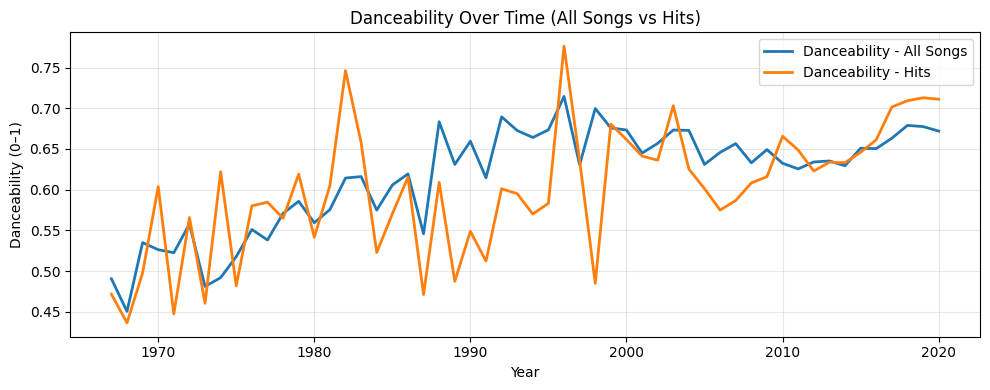

In [ ]:
# Danceability Over Time: All vs Hits

plt.figure(figsize=(10, 4))

plt.plot(all_aligned["release_year"], all_aligned["danceability"],
         label="Danceability - All Songs", linewidth=2)
plt.plot(hits_aligned["release_year"], hits_aligned["danceability"],
         label="Danceability - Hits", linewidth=2)

plt.title("Danceability Over Time (All Songs vs Hits)")
plt.xlabel("Year")
plt.ylabel("Danceability (0–1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Danceability Over Time: All Songs vs Hits
- Danceability increasesfavorsily across decades.  
- Hit songs often score slightly higher, especially in recent years.  
- Modern popular music favors strong rhythm and groove, influenced by pop, hip-hop, and EDM.


### Acousticness Over Time: All Songs vs Hits
- Acousticness declines over time as electronic and digital production become dominant.  
- Hit songs generally follow the same pattern and are slightly less acoustic on average.  
- Reflects industry shift toward highly produced electronic sounds.


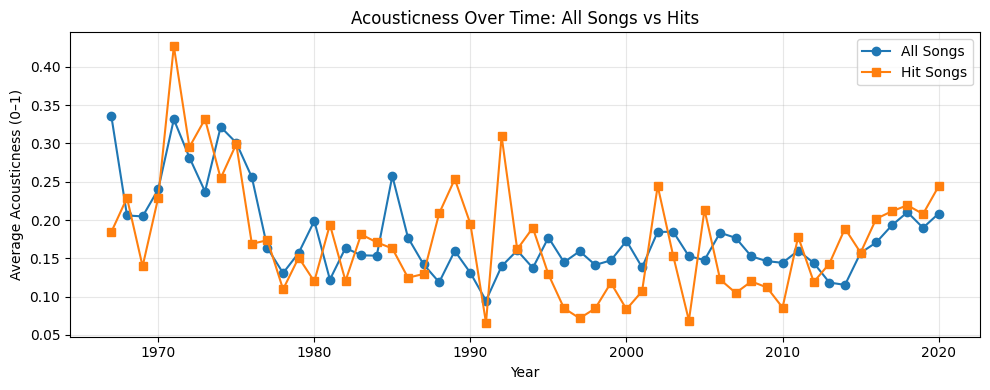

In [ ]:
# Acousticness: All Songs vs Hits

plt.figure(figsize=(10, 4))
plt.plot(
    all_aligned["release_year"], all_aligned["acousticness"],
    marker="o", label="All Songs"
)
plt.plot(
    hits_aligned["release_year"], hits_aligned["acousticness"],
    marker="s", label="Hit Songs"
)

plt.title("Acousticness Over Time: All Songs vs Hits")
plt.xlabel("Year")
plt.ylabel("Average Acousticness (0–1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Tempo Over Time: All Songs vs Hits
- Tempo remains relatively stable with no strong upward or downward trend.  
- Hit songs show more variability but follow a similar overall range.  
- Tempo alone is not a major differentiator of popularity.


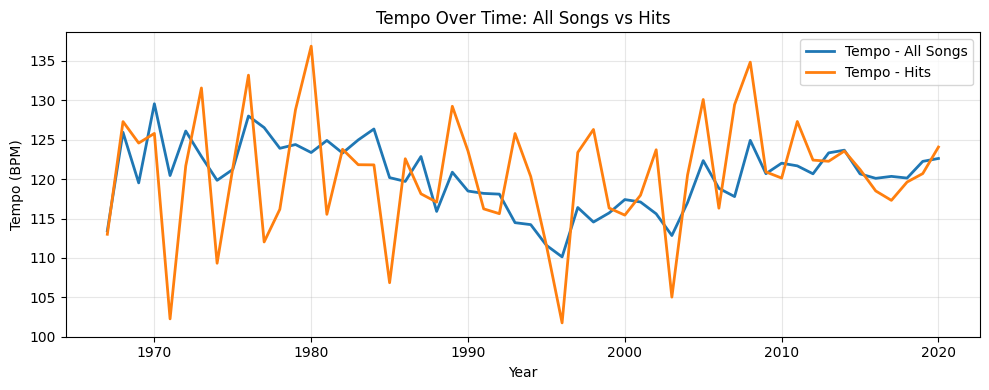

In [ ]:
# Tempo Over Time: All Songs vs Hits

plt.figure(figsize=(10, 4))

plt.plot(
    all_aligned["release_year"], all_aligned["tempo"],
    linewidth=2, label="Tempo - All Songs"
)

plt.plot(
    hits_aligned["release_year"], hits_aligned["tempo"],
    linewidth=2, label="Tempo - Hits"
)

plt.title("Tempo Over Time: All Songs vs Hits")
plt.xlabel("Year")
plt.ylabel("Tempo (BPM)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


- Modeling modern music data and exploring which features predict song success

In [ ]:
# Install DMBA utilities (only needed once per Colab runtime)
!pip install dmba

# Core libraries
import pandas as pd
import numpy as np

# Statsmodels for logistic regression (similar to S6 notebook)
import statsmodels.api as sm

# Visualization
import matplotlib.pyplot as plt

# Scikit-learn tools
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
# DMBA utilities (used heavily in the class notebooks)
from dmba import classificationSummary, gainsChart, liftChart


In [ ]:
# Load the Spotify dataset
path = "/content/drive/MyDrive/Colab Notebooks/Python Group Project/spotify_songs.csv"
spotify_df = pd.read_csv(path)

print("Shape of original data:", spotify_df.shape)
spotify_df.head()


Shape of original data: (32833, 23)


,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


I am adding a new column called vibe which are 4 emotional profiles made based on measures of energy and valence which are commonly used to determine a songs mood and classify music on Spotify.

Valence: conveys songs emotional tone
Energy: conveys songs intenesity


Classifying songs as:

Relaxed - Low Energy, High valence: colloquially referred to as "chill" music.
Happy - High Energy, High Sad Valence
Sad - Low Energy, Low Valence
Angry - High energy, Low Valence

In [ ]:
#filtering data to after 2010 for modern music
spotify_df["release_date"] = pd.to_datetime(spotify_df["track_album_release_date"], errors="coerce")
spotify_df = spotify_df.dropna(subset=["release_date"])
spotify_df["release_year"] = spotify_df["release_date"].dt.year

#function calculating medians for mood clusters
energy_median = spotify_df['energy'].median()
valence_median = spotify_df['valence'].median()

def classify_mood(row):
    is_high_energy = row['energy'] >= energy_median
    is_high_valence = row['valence'] >= valence_median

    if is_high_energy and is_high_valence:
        return 'happy'
    elif not is_high_energy and is_high_valence:
        return 'relaxed'
    elif is_high_energy and not is_high_valence:
        return 'angry'
    else: # Must be Low Energy and Low Valence
        return 'sad'
spotify_df['mood'] = spotify_df.apply(classify_mood, axis=1)
spotify_df

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,release_date,release_year,mood
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,194754,2019-06-14,2019,happy
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0373,0.072400,0.004210,0.3570,0.6930,99.972,162600,2019-12-13,2019,happy
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0742,0.079400,0.000023,0.1100,0.6130,124.008,176616,2019-07-05,2019,happy
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.1020,0.028700,0.000009,0.2040,0.2770,121.956,169093,2019-07-19,2019,angry
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,189052,2019-03-05,2019,happy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32828,7bxnKAamR3snQ1VGLuVfC1,City Of Lights - Official Radio Edit,Lush & Simon,42,2azRoBBWEEEYhqV6sb7JrT,City Of Lights (Vocal Mix),2014-04-28,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,204375,2014-04-28,2014,angry
32829,5Aevni09Em4575077nkWHz,Closer - Sultan & Ned Shepard Remix,Tegan and Sara,20,6kD6KLxj7s8eCE3ABvAyf5,Closer Remixed,2013-03-08,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,353120,2013-03-08,2013,angry
32830,7ImMqPP3Q1yfUHvsdn7wEo,Sweet Surrender - Radio Edit,Starkillers,14,0ltWNSY9JgxoIZO4VzuCa6,Sweet Surrender (Radio Edit),2014-04-21,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0.0481,0.108000,0.000001,0.1500,0.4360,127.989,210112,2014-04-21,2014,angry
32831,2m69mhnfQ1Oq6lGtXuYhgX,Only For You - Maor Levi Remix,Mat Zo,15,1fGrOkHnHJcStl14zNx8Jy,Only For You (Remixes),2014-01-01,♥ EDM LOVE 2020,6jI1gFr6ANFtT8MmTvA2Ux,edm,...,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,367432,2014-01-01,2014,angry


In [ ]:

print("Distribution of 'mood' categories:")
print(spotify_df['mood'].value_counts())

Distribution of 'mood' categories:
mood
happy      8499
sad        8421
angry      7036
relaxed    6991
Name: count, dtype: int64


In [ ]:
#viewing data type
spotify_df.dtypes

,0
track_id,object
track_name,object
track_artist,object
track_popularity,int64
track_album_id,object
track_album_name,object
track_album_release_date,object
playlist_name,object
playlist_id,object
playlist_genre,object


In [ ]:
# Define 'hit' based on popularity score (re-run as spotify_df might have been reloaded)
spotify_df['hit'] = (spotify_df['track_popularity'] >= 70).astype(int)

#analyzing + visualizing hitrate based on mood
hit_rate_by_mood = spotify_df.groupby('mood')['hit'].mean().sort_values(ascending=True) #grouping by mood
hit_rate_df = hit_rate_by_mood.reset_index()
hit_rate_df.columns = ['Mood', 'Hit Rate']


hit_rate_df['Hit Rate'] = hit_rate_df['Hit Rate'] * 100 #turning into percentage

hit_rate_df


,Mood,Hit Rate
0,angry,8.911313
1,happy,15.190022
2,relaxed,17.794307
3,sad,17.848237


### Mood (Valence x Energy) Over Time: All Songs vs Hits
- Valence shows a downward trend, meaning songs (including hits) are becoming less “happy.”  
- Hit songs fluctuate more year-to-year but track closely with the overall trend.  
- Modern music leans toward more emotional, melancholic tones.


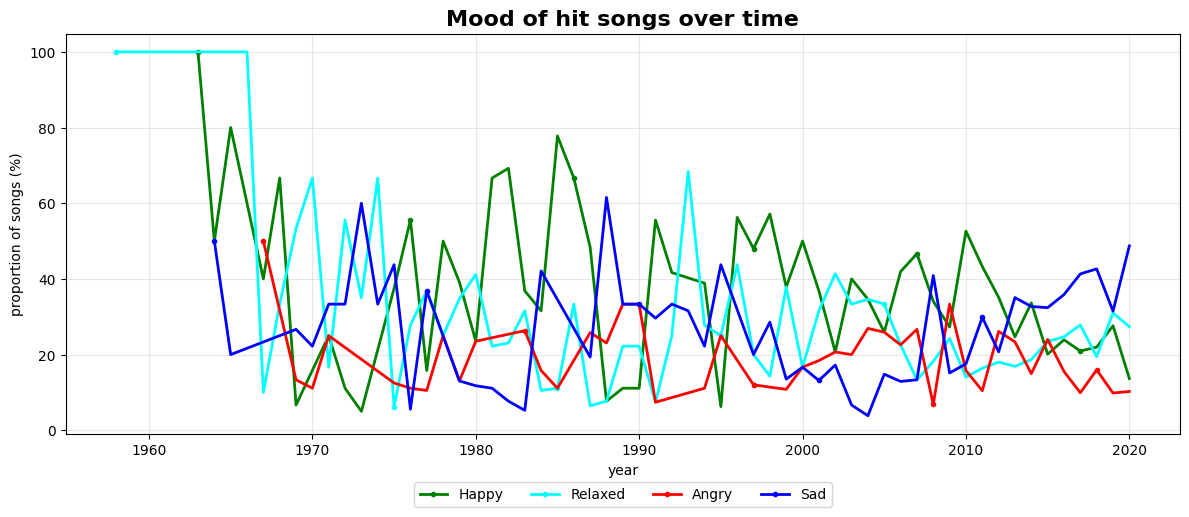

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# make sure 'release_year' is an integer
spotify_df['release_year'] = spotify_df['release_year'].astype(int)

# 1. filter for hits using the column name 'hit'
# we assume 'hit' is a boolean column (True/False)
hits_df = spotify_df[spotify_df['hit'] == True]

# 2. calculate mood proportions for hits
# use value_counts(normalize=True) to get proportions per year
hits_mood_proportions = (
    hits_df.groupby('release_year')['mood']
    .value_counts(normalize=True)
    .mul(100) # convert to percentage
    .rename('proportion')
    .reset_index()
)

# define custom moods and colors for plotting
mood_categories = ["happy", "relaxed", "angry", "sad"]
mood_colors = {
    "happy": "green",
    "relaxed": "cyan",
    "angry": "red",
    "sad": "blue"
}

# create the figure
plt.figure(figsize=(12, 6))

# plot hits for each mood category
for mood in mood_categories:
    color = mood_colors[mood]

    # filter data for the current mood
    hits_mood_data = hits_mood_proportions[hits_mood_proportions['mood'] == mood]

    # plot hits (solid line with marker)
    plt.plot(
        hits_mood_data["release_year"],
        hits_mood_data["proportion"],
        linewidth=2,
        label=f"{mood.capitalize()}", # simplified label
        color=color,
        linestyle='-', # solid line
        marker='o',
        markersize=3,
        markevery=10
    )

# set titles, labels, and legend
plt.title(
    "Mood of hit songs over time",
    fontsize=16,
    fontweight='bold'
)
plt.xlabel("year")
plt.ylabel("proportion of songs (%)")

# place legend below the chart
plt.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.2))

# draw the grid
plt.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0.1, 1, 1])

# show the plot
plt.show()

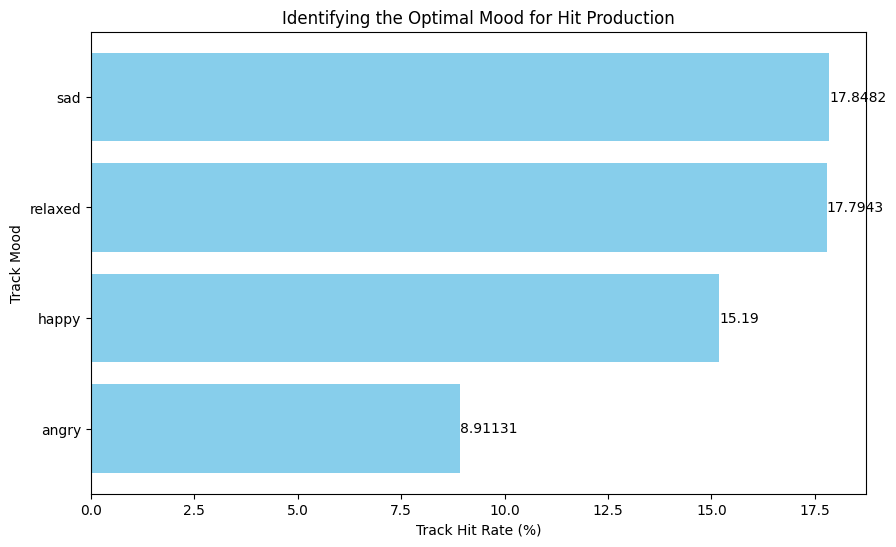

In [ ]:

#visualizing hit rate by mood
plt.figure(figsize=(10, 6))
plt.barh(hit_rate_df['Mood'], hit_rate_df['Hit Rate'], color='skyblue')
plt.xlabel('Track Hit Rate (%)')
plt.ylabel('Track Mood')
plt.title('Identifying the Optimal Mood for Hit Production')
#adding numerical values to bars
plt.bar_label(barh, fontsize=10, color='black')
plt.show()

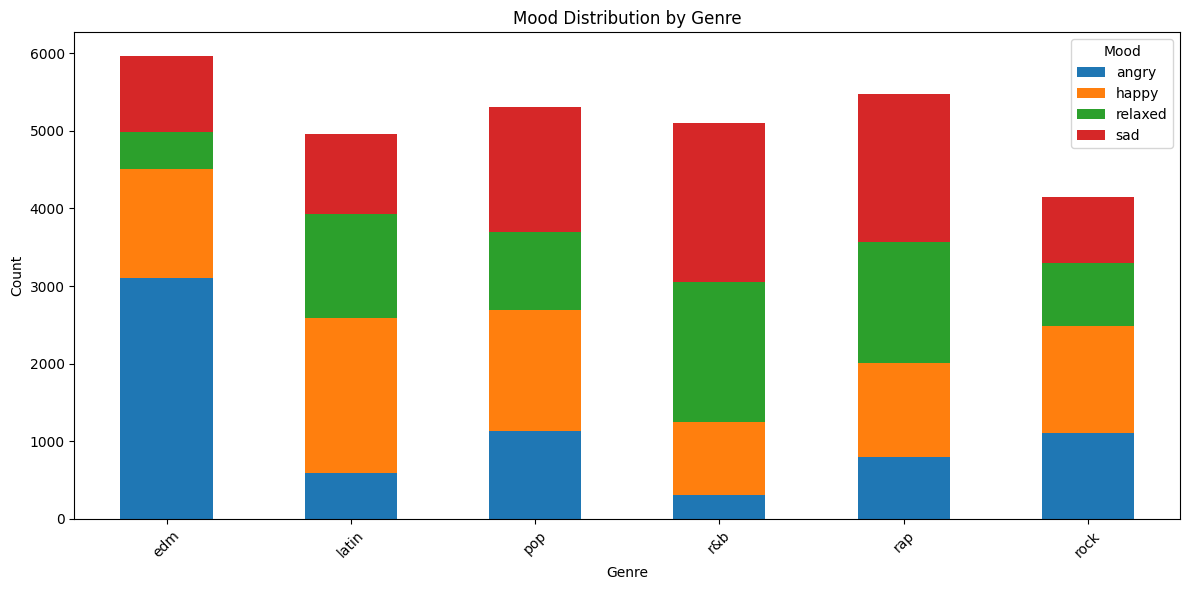

In [ ]:
#mood by genre
genre_mood_counts = spotify_df.groupby(['playlist_genre', 'mood']).size().unstack(fill_value=0)
mood_categories = ["happy", "relaxed", "angry", "sad"]
mood_colors = {
    "happy": "green",
    "relaxed": "cyan",
    "angry": "red",
    "sad": "blue"
}

ax = genre_mood_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Mood Distribution by Genre')
plt.legend(title='Mood')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Modeling: Linear Regression Classification Model

In this model angry mood is used as the reference category for the logistic regression model because it has the lowest commercial success (hit rate).

In [ ]:
# Choose audio features for modeling (independent variables)
feature_cols = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

# Building modeling dataset: only features + target
model_df = spotify_df[feature_cols + ['hit']].dropna().copy()

# Getting dummies of categorical data from the 'mood' column
mood_dummy = pd.get_dummies(spotify_df['mood'], prefix='mood')

#merging with mood dummy variable
model_df = pd.concat([model_df, mood_dummy], axis=1).astype('float64')

mood_features = ['mood_happy', 'mood_relaxed', 'mood_sad']

# Separate features (X) and target (y)
X = model_df[feature_cols + mood_features]
y = model_df['hit']

#verifying shape
print("Shape of modeling data:", model_df.shape)
model_df.head()


Shape of modeling data: (30947, 15)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,hit,mood_angry,mood_happy,mood_relaxed,mood_sad
0,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754.0,0.0,0.0,1.0,0.0,0.0
1,0.726,0.815,-4.969,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600.0,0.0,0.0,1.0,0.0,0.0
2,0.675,0.931,-3.432,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616.0,1.0,0.0,1.0,0.0,0.0
3,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093.0,0.0,1.0,0.0,0.0,0.0
4,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
# 40% for validation + testing
train_X, temp_X, train_y, temp_y = train_test_split(X, y, test_size=0.4, random_state=1)

# split that 40% equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(temp_X, temp_y, test_size=0.5, random_state=1)


In [ ]:
#training
train_X = train_X.reset_index(drop=True)
train_y = train_y.reset_index(drop=True)

# Add constant
X_train_sm = sm.add_constant(train_X)

# Fit GLM
logit_model = sm.GLM(train_y, X_train_sm, family=sm.families.Binomial())
logit_result = logit_model.fit()

In [ ]:
from sklearn.metrics import classification_report
# Add constant term (intercept), as done in S6 for Universal Bank
X_valid = X_val.reset_index(drop=True)
y_valid = y_val.reset_index(drop=True)

#adding constant
X_valid_sm = sm.add_constant(X_val, prepend=True)

# Predicted probabilities for the validation set
logit_pred_proba = logit_result.predict(X_valid_sm)

# Convert probabilities to class labels using cutoff 0.5
logit_pred_class_05 = np.where(logit_pred_proba > 0.5, 1, 0)

# Use DMBA classificationReport (same style as class)
print("=== Logistic Regression (cutoff = 0.5) ===")
print(classification_report(y_valid, logit_pred_class_05))


=== Logistic Regression (cutoff = 0.5) ===
              precision    recall  f1-score   support

         0.0       0.84      1.00      0.92      5224
         1.0       0.00      0.00      0.00       965

    accuracy                           0.84      6189
   macro avg       0.42      0.50      0.46      6189
weighted avg       0.71      0.84      0.77      6189



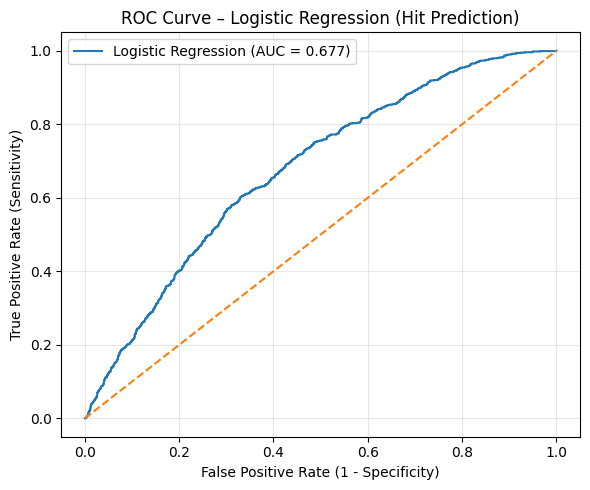

In [ ]:
# Compute ROC curve and AUC for logistic regression
fpr_log, tpr_log, thresholds_log = roc_curve(y_valid, logit_pred_proba)
auc_log = roc_auc_score(y_valid, logit_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve – Logistic Regression (Hit Prediction)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


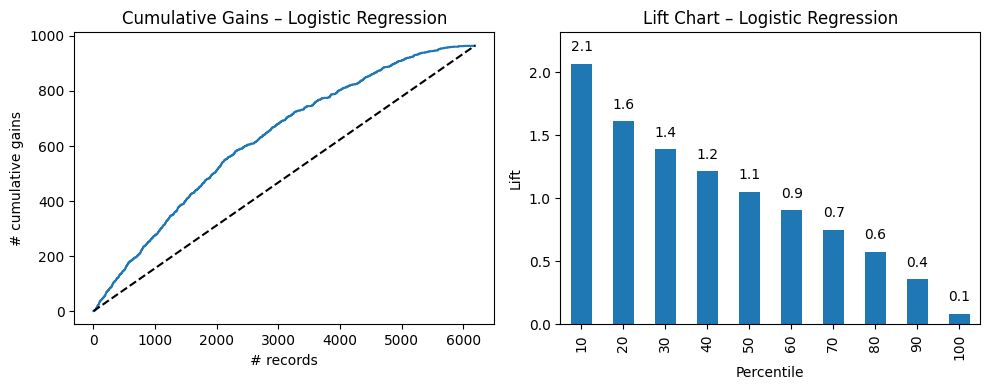

In [ ]:
# Build a DataFrame for gains and lift, similar to logit_result_vl in S6
logit_valid_df = pd.DataFrame({
    'actual': y_valid.values,
    'p(1)': logit_pred_proba
})

# Sort by highest probability of being a hit
logit_valid_df = logit_valid_df.sort_values(by='p(1)', ascending=False)

# Plot gains and lift charts using DMBA utilities
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

gainsChart(logit_valid_df.actual, ax=axes[0])
axes[0].set_title('Cumulative Gains – Logistic Regression')

liftChart(logit_valid_df['p(1)'], title=False, ax=axes[1])
axes[1].set_title('Lift Chart – Logistic Regression')

plt.tight_layout()
plt.show()


Since the linear regression model has high accuracy but low recall the next step will be making and tuning a RFclassifier model.

In [ ]:
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    GradientBoostingClassifier
)
#base tree
base_tree = DecisionTreeClassifier(max_depth=10, class_weight='balanced', random_state=1)

#training "Bagginglassifer", "BoostingClassifier" and "RFClassiefier" models
moodreg_rf = RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=1)
moodreg_rf.fit(train_X, train_y)

#bagging
moodreg_bag = BaggingClassifier(estimator=base_tree, n_estimators=100, max_features=1.0, random_state=1)
moodreg_bag.fit(train_X, train_y)

#boosting
moodreg_boost = GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.01, random_state=1)
moodreg_boost.fit(train_X, train_y)

GradientBoostingClassifier(learning_rate=0.01, random_state=1)

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, recall_score

#getting predicted values
bag_pred = moodreg_bag.predict(train_X)
boost_pred = moodreg_boost.predict(train_X)
RF_pred = moodreg_rf.predict(train_X)

#getting summary
print("\n === Bagging Classifier ===")
classificationSummary(train_y, bag_pred)

print("\n === Boosting Classifier ===")
classificationSummary(train_y, boost_pred)

print("\n === Random Forest Classifier ===")
classificationSummary(train_y, RF_pred)


 === Bagging Classifier ===
Confusion Matrix (Accuracy 0.8467)

       Prediction
Actual     0     1
     0 13134  2641
     1   206  2587

 === Boosting Classifier ===
Confusion Matrix (Accuracy 0.8496)

       Prediction
Actual     0     1
     0 15775     0
     1  2793     0

 === Random Forest Classifier ===
Confusion Matrix (Accuracy 0.8166)

       Prediction
Actual     0     1
     0 12651  3124
     1   281  2512


Based on the classification report the random forest model was most accurate in correctly predicting true positives compared to other models so this will be the model tuned.

In [ ]:
#before tuning
RF_pred_proba = moodreg_rf.predict_proba(X_val)[:, 1]

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
RF_pred_class = np.where(RF_pred_proba > 0.5, 1, 0)

auc_score_val = roc_auc_score(y_val, RF_pred_proba)

#printing
print("\n === Tuned Random Forest Classifier ===")
print(classification_report(y_val, RF_pred_class))
classificationSummary(y_val, RF_pred_class)


 === Tuned Random Forest Classifier ===
              precision    recall  f1-score   support

         0.0       0.93      0.77      0.85      5224
         1.0       0.36      0.68      0.47       965

    accuracy                           0.76      6189
   macro avg       0.64      0.73      0.66      6189
weighted avg       0.84      0.76      0.79      6189

Confusion Matrix (Accuracy 0.7609)

       Prediction
Actual    0    1
     0 4048 1176
     1  304  661


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score, recall_score
#printing classification report of RF classifier on validation data
X_valid = X_val.reset_index(drop=True)
y_valid = y_val.reset_index(drop=True)

#adding constant
RF_valid_pred = moodreg_rf.predict(X_valid)
RF_valid_proba = moodreg_rf.predict_proba(X_valid)[:, 1]

print("=== Random Forest Validation Report ===")
print(classification_report(y_valid, RF_valid_pred))
auc_score = roc_auc_score(y_valid, RF_valid_proba)
recall_score = recall_score(y_valid, RF_valid_pred)
print("AUC Score:", auc_score)
print("Recall Score:", recall_score)

=== Random Forest Validation Report ===
              precision    recall  f1-score   support

         0.0       0.93      0.77      0.85      5224
         1.0       0.36      0.68      0.47       965

    accuracy                           0.76      6189
   macro avg       0.64      0.73      0.66      6189
weighted avg       0.84      0.76      0.79      6189

AUC Score: 0.8110564830316831
Recall Score: 0.6849740932642487


Model Tuning: Tuning RFClassifier model hyperparameters

In [ ]:
#tuning RFClassifer model hyperparameters
from sklearn.model_selection import GridSearchCV

#set the gridsearch parameters
param_grid={'n_estimators': [200, 300, 400],
            'max_depth':[None, 10],
            'min_samples_leaf': [2, 5],
            'min_samples_split':[2, 5, 10],
            'class_weight':['balanced'],
            'max_features': ['sqrt', None],
            'random_state':[1]
            }
#defining gridsearch
rf_estimator = RandomForestClassifier(n_jobs=-1)
grid_search = GridSearchCV(rf_estimator, param_grid, scoring='recall', cv=5, verbose=2)

#fitting model on training data
grid_search.fit(train_X, train_y)

#results
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Recall Score:", best_score)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200, random_state=1; total time=  20.6s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200, random_state=1; total time=   8.7s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200, random_state=1; total time=   6.8s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200, random_state=1; total time=   8.6s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=200, random_state=1; total time=   6.6s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=2, min_samples_split=2, n_estimators=300, random_

In [ ]:

#setting rf model to best model
moodreg_rf_tuned = RandomForestClassifier(n_estimators=400, max_features='sqrt', max_depth=20, min_samples_split=2, min_samples_leaf=2, class_weight='balanced', random_state=1)

moodreg_rf_tuned.fit(train_X, train_y)

#checking classification report on validation data
RF_tuned_pred = moodreg_rf_tuned.predict(X_val)

#getting probabilities
RF_tuned_proba = moodreg_rf_tuned.predict_proba(X_val)[:, 1]
auc_score_val = roc_auc_score(y_val, RF_tuned_proba)

#printing
print("\n === Tuned Random Forest Classifier ===")
print(classification_report(y_val, RF_tuned_pred))
classificationSummary(y_val, RF_tuned_pred)


 === Tuned Random Forest Classifier ===
              precision    recall  f1-score   support

         0.0       0.93      0.98      0.95      5224
         1.0       0.83      0.59      0.69       965

    accuracy                           0.92      6189
   macro avg       0.88      0.79      0.82      6189
weighted avg       0.91      0.92      0.91      6189

Confusion Matrix (Accuracy 0.9178)

       Prediction
Actual    0    1
     0 5108  116
     1  393  572


In [ ]:
#predicing on test data
test_pred = moodreg_rf_tuned.predict(X_test)
test_proba = moodreg_rf_tuned.predict_proba(X_test)[:, 1]
auc_score_test = roc_auc_score(y_test, test_proba)

print("\n === Tuned Random Forest Classifier ===")
print(classification_report(y_test, test_pred))


 === Tuned Random Forest Classifier ===
              precision    recall  f1-score   support

         0.0       0.93      0.97      0.95      5283
         1.0       0.80      0.60      0.68       907

    accuracy                           0.92      6190
   macro avg       0.87      0.79      0.82      6190
weighted avg       0.91      0.92      0.91      6190



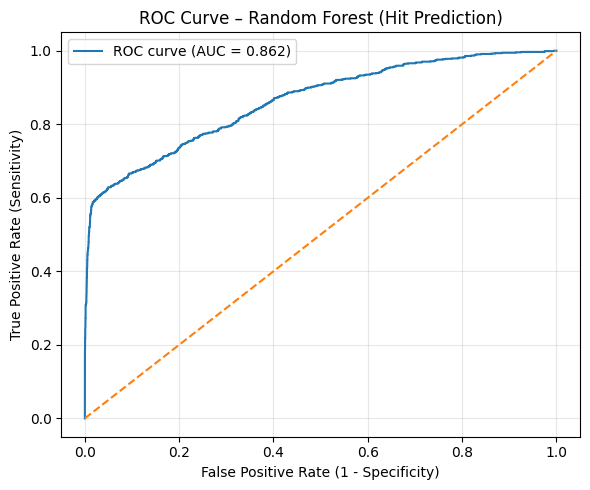

In [ ]:
#building roc and gain and lift chart of best model on test data
fpr, tpr, thresholds = roc_curve(y_test, test_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc_score_test:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve – Random Forest (Hit Prediction)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


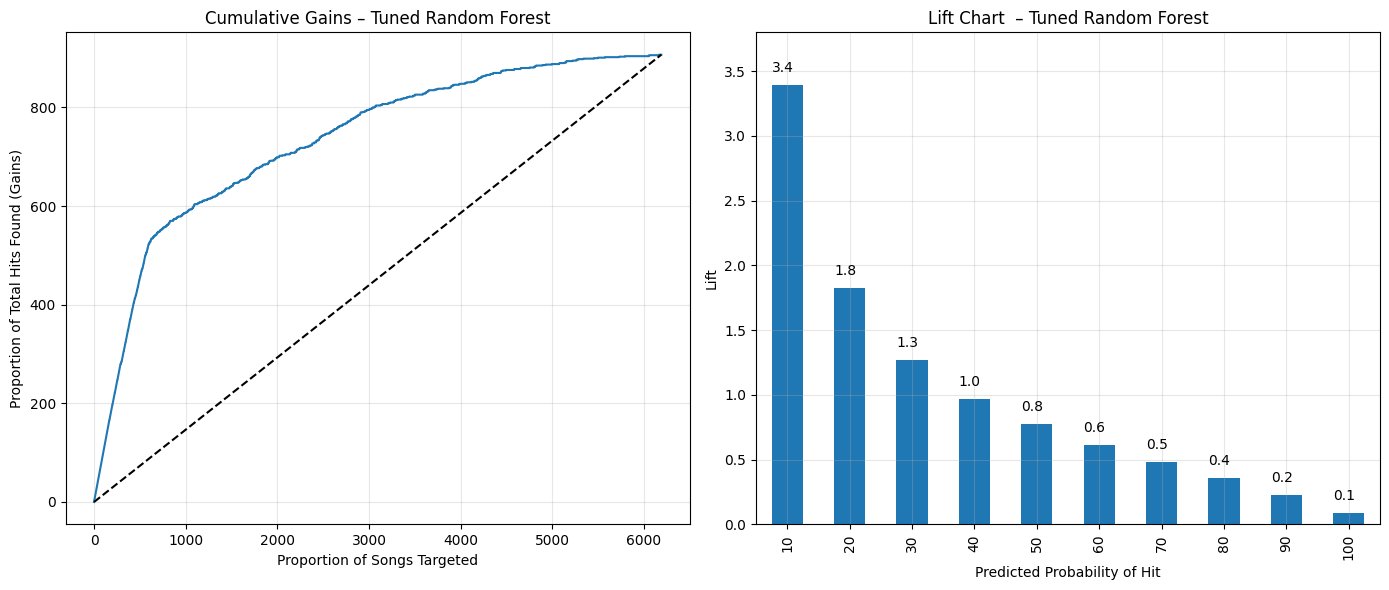

In [ ]:

# Build a DataFrame for gains and lift, using test data
rf_test_df = pd.DataFrame({
    'actual': y_test.values,
    'p(1)': test_proba
})

# Sort by highest probability of being a hit
rf_test_df = rf_test_df.sort_values(by='p(1)', ascending=False)

# Plot gains and lift charts using DMBA utilities
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

gainsChart(rf_test_df.actual, ax=axes[0])
axes[0].set_title('Cumulative Gains – Tuned Random Forest')
axes[0].set_xlabel('Proportion of Songs Targeted')
axes[0].set_ylabel('Proportion of Total Hits Found (Gains)')
axes[0].grid(True, alpha=0.3);

liftChart(rf_test_df['p(1)'], title=False, ax=axes[1])
axes[1].set_title('Lift Chart  – Tuned Random Forest')
axes[1].set_xlabel('Predicted Probability of Hit')
axes[1].set_ylabel('Lift') # Changed ylabel for lift chart
axes[1].grid(True, alpha=0.3);

#fitting charts together
plt.tight_layout()
plt.show()

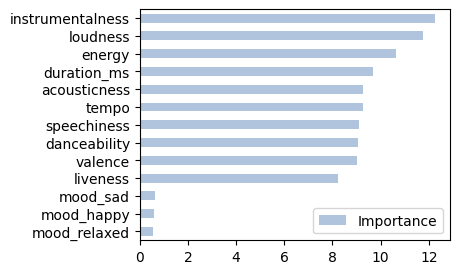

In [ ]:
#variable importance plot

feature_names = X.columns.tolist()
Importance = pd.DataFrame({
    'Importance': moodreg_rf_tuned.feature_importances_*100}, \
    index=feature_names)

Importance.sort_values('Importance', axis=0, ascending=True).plot(kind='barh', color='lightsteelblue', ) # kind='barh' : Horizontal bar
plt.gcf().set_size_inches(4, 3)


SHAP explainer for Tuned Random Forest (Test Data)


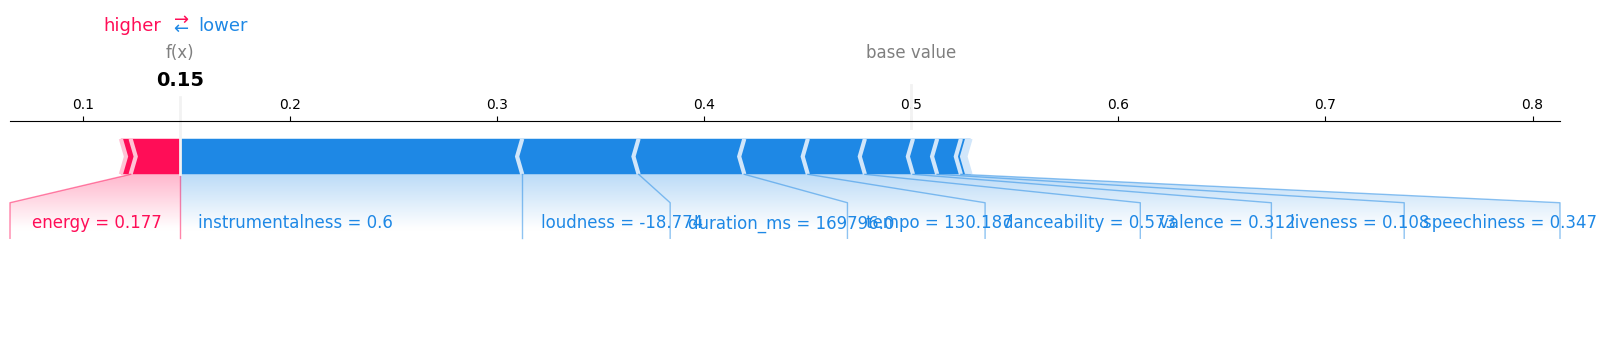

In [ ]:
import shap
#shap explainer
explainer = shap.TreeExplainer(moodreg_rf_tuned)
expected_value = explainer.expected_value
shap.initjs()

#limiting data size for efficiency (was taking long to run)
X_sample = X_test.sample(n=500, random_state=1)

print(f"\nSHAP explainer for Tuned Random Forest (Test Data)")
# Ensure shap_values_sample has the correct shape (n_samples, n_features)
shap_values_list = explainer.shap_values(X_sample)
# Correctly extract SHAP values for the positive class (class 1) for all samples
shap_values_sample = shap_values_list[:, :, 1]
shap.force_plot(expected_value[1], shap_values_sample[0,:], X_sample.iloc[0,:], matplotlib=True)

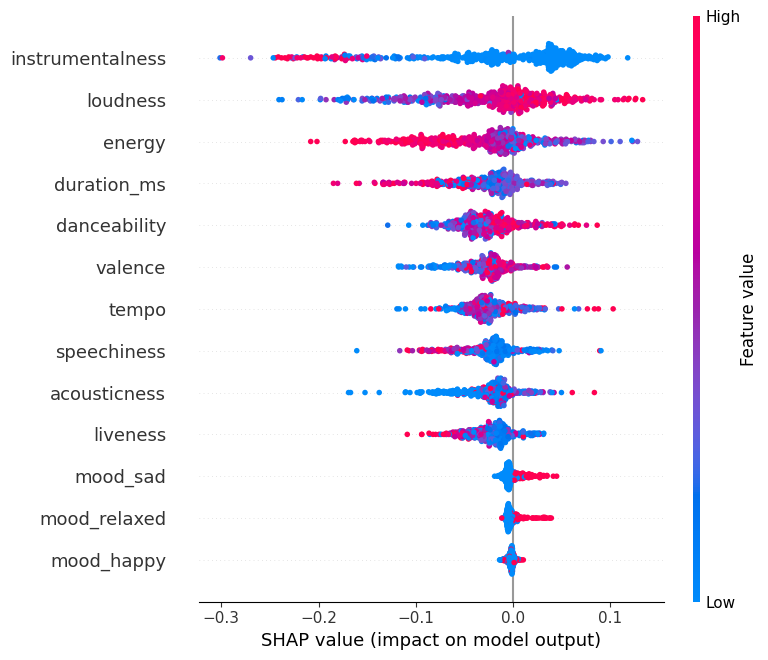

In [ ]:
import shap
#shap summary plot  presentation
shap.summary_plot(shap_values_sample, X_sample)